```text
international airline 데이터
-----------------------

- EDA 수행: 기술통계값 등
- acf, pacf 그래프 ,adfuller지수 시계열확인
- 시계열분해
- ARIMA 이용 1년 예측
- SARIMA 이용 1년 예측
- autoarim 이용 1년 예측


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sb
import matplotlib.dates as mdates
from matplotlib import rcParams
from statsmodels.tsa.stattools import acf,adfuller
from statsmodels.tsa.ar_model import AutoReg
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from warnings import filterwarnings
filterwarnings("ignore")

plt.rcParams['font.family'] ='Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False

In [2]:
airDF = pd.read_csv('../시계열/data/international-airline-passengers.txt',
                    index_col='time', parse_dates=['time'])
airDF


,passengers
time,
1949-01-01,112
1949-02-01,118
1949-03-01,132
1949-04-01,129
1949-05-01,121
...,...
1960-08-01,606
1960-09-01,508
1960-10-01,461


In [3]:
airDF.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 144 entries, 1949-01-01 to 1960-12-01
Data columns (total 1 columns):
 #   Column      Non-Null Count  Dtype
---  ------      --------------  -----
 0   passengers  144 non-null    int64
dtypes: int64(1)
memory usage: 2.2 KB


- EDA 수행

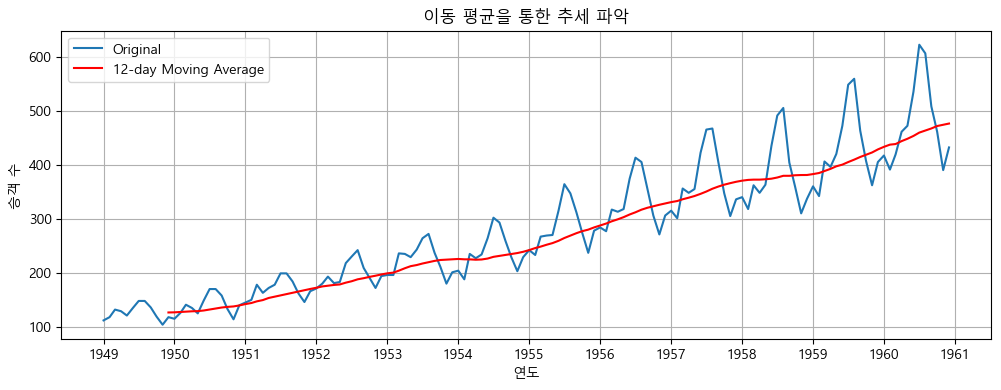

In [4]:
# 추세 파악

# 이동평균
airDF['MA_12'] = airDF['passengers'].rolling(window=12).mean()

plt.figure(figsize=(12,4))
plt.plot(airDF.index, airDF['passengers'], label='Original')
plt.plot(airDF.index, airDF['MA_12'], label='12-day Moving Average', color='red')

plt.title('이동 평균을 통한 추세 파악')
plt.xlabel('연도')
plt.ylabel('승객 수')

# 축 설정
plt.gca().xaxis.set_major_locator(mdates.YearLocator())
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%Y'))

plt.legend()
plt.grid(True)
plt.show()


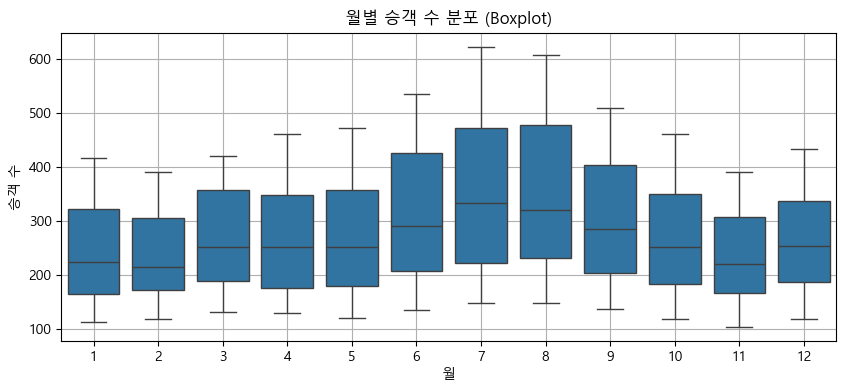

In [5]:
airDF['month'] = airDF.index.month

plt.figure(figsize=(10,4))
sb.boxplot(x='month', y='passengers', data=airDF)

plt.title('월별 승객 수 분포 (Boxplot)')
plt.xlabel('월')
plt.ylabel('승객 수')
plt.grid(True)
plt.show()



- acf, pacf 그래프, adfuller지수 시계열 확인

In [6]:
passengers = airDF['passengers'].values

In [7]:
np.corrcoef(passengers[1:], passengers[:-1])

array([[1.        , 0.96019465],
       [0.96019465, 1.        ]])

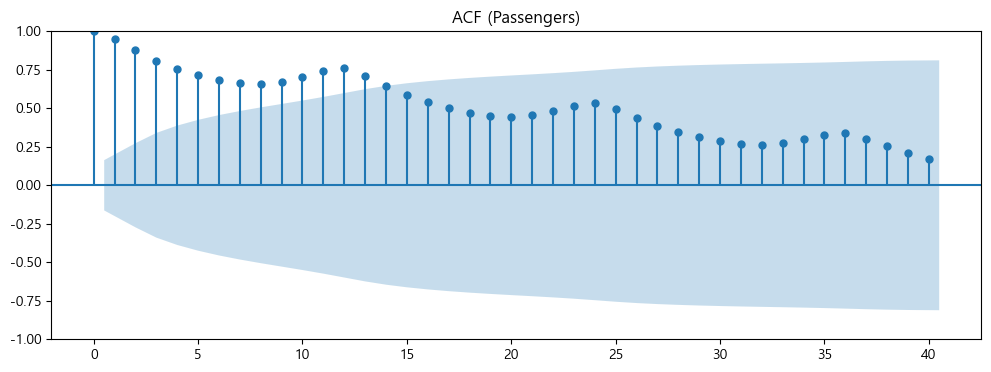

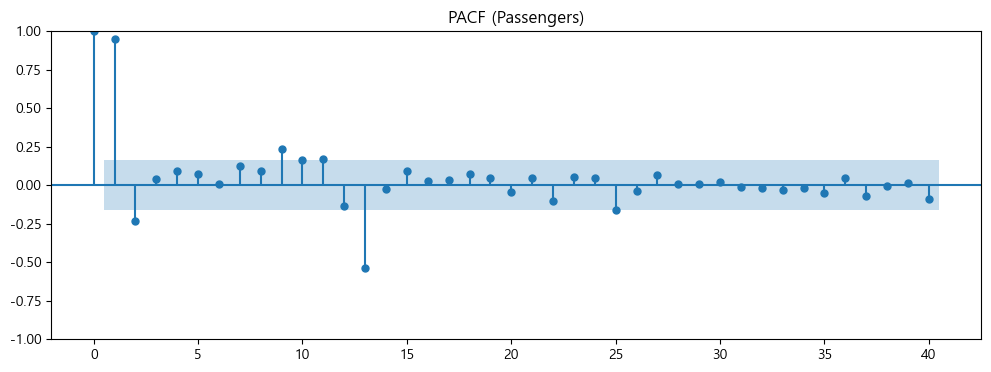

Lag별 p-value
Lag 1: p-value = 0.0000
Lag 2: p-value = 0.0000
Lag 3: p-value = 0.0000
Lag 4: p-value = 0.0000
Lag 5: p-value = 0.0000
Lag 6: p-value = 0.0000
Lag 7: p-value = 0.0000
Lag 8: p-value = 0.0000
Lag 9: p-value = 0.0000
Lag 10: p-value = 0.0000
Lag 11: p-value = 0.0000
Lag 12: p-value = 0.0000
Lag 13: p-value = 0.0000
Lag 14: p-value = 0.0000
Lag 15: p-value = 0.0000
Lag 16: p-value = 0.0000
Lag 17: p-value = 0.0000
Lag 18: p-value = 0.0000
Lag 19: p-value = 0.0000
Lag 20: p-value = 0.0000
Lag 21: p-value = 0.0000
Lag 22: p-value = 0.0000
Lag 23: p-value = 0.0000
Lag 24: p-value = 0.0000
 자기상관 있음 → 비정상 가능성 높음


In [8]:

acf_vals, confint, qstat, pvalues = acf(passengers, nlags=24, alpha=0.05, qstat=True)

rcParams['figure.figsize'] = (12, 4)

#ACF
plot_acf(airDF['passengers'], lags=40)
plt.title('ACF (Passengers)')
plt.show()

# PACF
plot_pacf(airDF['passengers'], lags=40, method='ywm')
plt.title('PACF (Passengers)')
plt.show()

#  각 lag에 대한 p-value 출력
print("Lag별 p-value")
for i, p in enumerate(pvalues):
    print(f"Lag {i+1}: p-value = {p:.4f}")

if pvalues[-1] < 0.05:
    print(" 자기상관 있음 → 비정상 가능성 높음")
else:
    print(" 자기상관 없음 → 정상 시계열 가능성 있음")


In [9]:
result = adfuller(passengers)
print("ADF Test")
print(f"ADF 통계량: {result[0]:.4f}")
print(f"p-value: {result[1]:.4f}")

if result[1] < 0.05:
    print("✅ 정상 시계열 (stationary)")
else:
    print("❌ 비정상 시계열 (non-stationary)")

ADF Test
ADF 통계량: 0.8154
p-value: 0.9919
❌ 비정상 시계열 (non-stationary)


- 시계열 분해

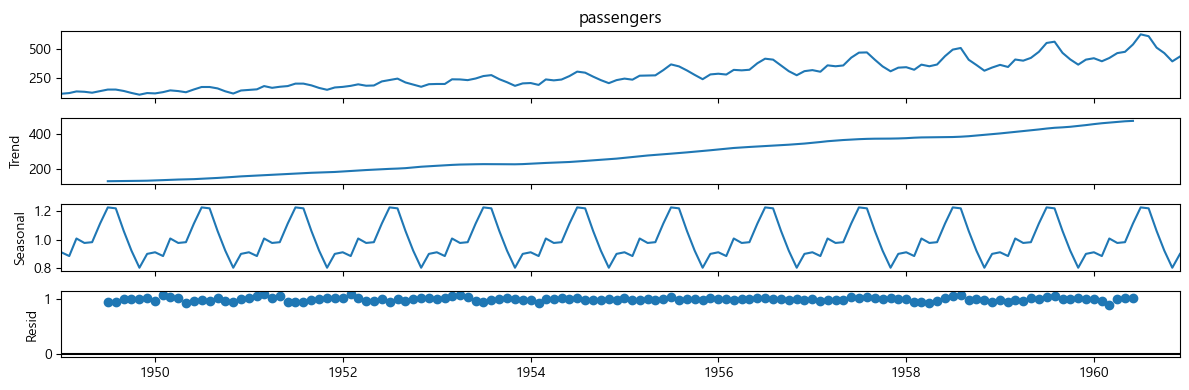

In [10]:
from statsmodels.tsa.seasonal import seasonal_decompose

decompose_result = seasonal_decompose(
    airDF['passengers'],
    model='multiplicative',
    period=12
)

decompose_result.plot()
plt.tight_layout()
plt.show()


- ARIMA 이용 1년 예측

차분 ADF Statistic: -2.8292668241699945
차분 p-value: 0.05421329028382621
❌ 비정상 시계열 → 차분 필요


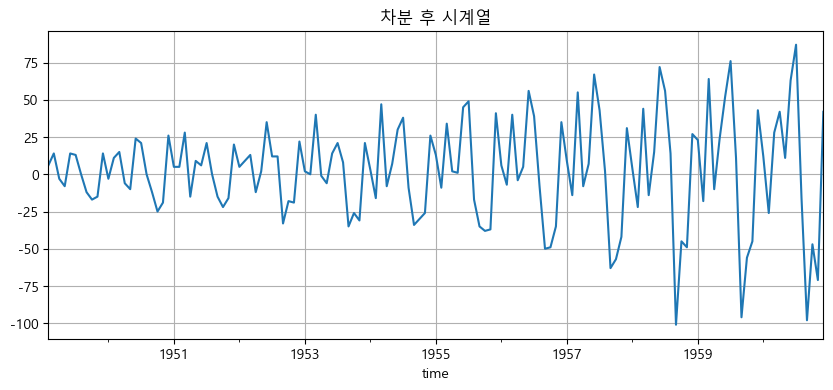

In [11]:
# 🔁 차분 후 정상성 확인

ts_diff = airDF['passengers'].diff().dropna() # 1.506821-0.496714, 3.786615-1.506821,.....

adf_result_diff = adfuller(ts_diff)
print("차분 ADF Statistic:", adf_result_diff[0])
print("차분 p-value:", adf_result_diff[1])
if adf_result_diff[1] < 0.05:
    print("✅ 정상 시계열 (stationary)")
else:
    print("❌ 비정상 시계열 → 차분 필요")
    
ts_diff.plot(title="차분 후 시계열", figsize=(10, 4))
plt.grid(True)
plt.show()

In [12]:
model = ARIMA(airDF['passengers'], order=(2, 2, 1))
result = model.fit()
print(result.summary())

                               SARIMAX Results                                
Dep. Variable:             passengers   No. Observations:                  144
Model:                 ARIMA(2, 2, 1)   Log Likelihood                -692.943
Date:                Sat, 20 Dec 2025   AIC                           1393.887
Time:                        14:00:39   BIC                           1405.710
Sample:                    01-01-1949   HQIC                          1398.691
                         - 12-01-1960                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.3845      0.092      4.194      0.000       0.205       0.564
ar.L2         -0.2259      0.071     -3.181      0.001      -0.365      -0.087
ma.L1         -0.9987      0.676     -1.478      0.1

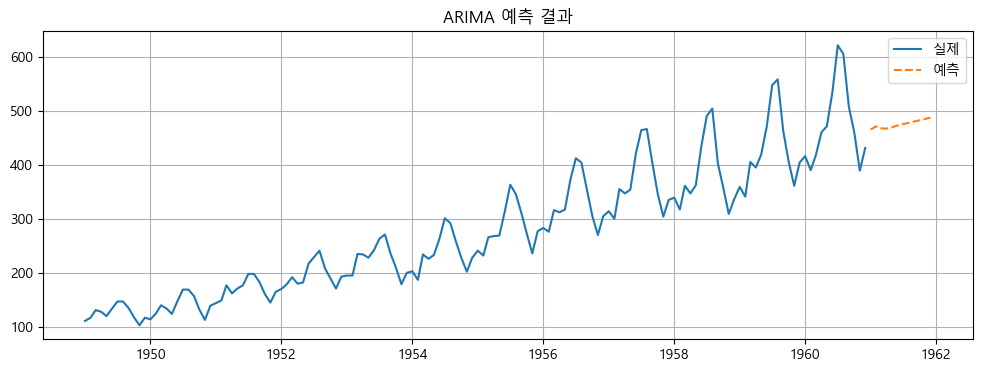

In [13]:
forecast = result.forecast(steps=12)

plt.plot(airDF['passengers'], label="실제")
plt.plot(pd.date_range(start=airDF.index[-1], periods=12, freq='ME'), forecast, label="예측", linestyle='--')
plt.title("ARIMA 예측 결과")
plt.legend()
plt.grid(True)
plt.show()

- SARIMA 이용 1년 예측

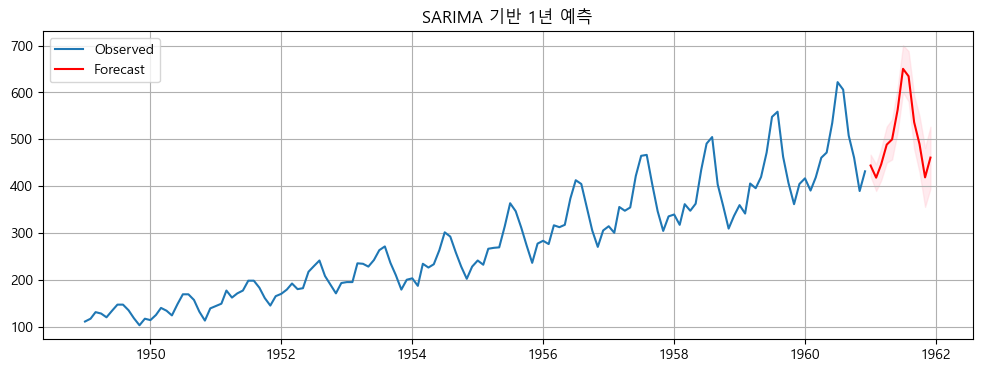

In [14]:
# SARIMA 이용 1년 예측

from statsmodels.tsa.statespace.sarimax import SARIMAX

model = SARIMAX(airDF['passengers'], order=(2,2,1), seasonal_order=(0,1,0,12))
result = model.fit()

# 향후 12개월 예측
forecast = result.get_forecast(steps=12)
forecast_mean = forecast.predicted_mean
conf_int = forecast.conf_int()

# 시각화
plt.plot(airDF.index, airDF['passengers'], label='Observed')
plt.plot(forecast_mean.index, forecast_mean, label='Forecast', color='red')
plt.fill_between(forecast_mean.index, conf_int.iloc[:,0], conf_int.iloc[:,1], color='pink', alpha=0.3)
plt.title("SARIMA 기반 1년 예측")
plt.legend()
plt.grid(True)
plt.show()

- autoarim 이용 1년 예측

In [15]:
from pmdarima import auto_arima

stepwise_model = auto_arima(
    airDF['passengers'],
    seasonal=True,
    m=12,
    trace=True,
    error_action='ignore',
    suppress_warnings=True,
    stepwise=True
)

print('=========================')
print("최적 모델 요약:")
stepwise_model.summary()

Performing stepwise search to minimize aic
 ARIMA(2,1,2)(1,1,1)[12]             : AIC=1020.048, Time=0.47 sec
 ARIMA(0,1,0)(0,1,0)[12]             : AIC=1031.508, Time=0.02 sec
 ARIMA(1,1,0)(1,1,0)[12]             : AIC=1020.393, Time=0.06 sec
 ARIMA(0,1,1)(0,1,1)[12]             : AIC=1021.003, Time=0.07 sec
 ARIMA(2,1,2)(0,1,1)[12]             : AIC=1019.935, Time=0.28 sec
 ARIMA(2,1,2)(0,1,0)[12]             : AIC=1019.290, Time=0.10 sec
 ARIMA(2,1,2)(1,1,0)[12]             : AIC=1019.546, Time=0.28 sec
 ARIMA(1,1,2)(0,1,0)[12]             : AIC=1024.160, Time=0.05 sec
 ARIMA(2,1,1)(0,1,0)[12]             : AIC=1017.847, Time=0.09 sec
 ARIMA(2,1,1)(1,1,0)[12]             : AIC=1017.914, Time=0.27 sec
 ARIMA(2,1,1)(0,1,1)[12]             : AIC=1018.359, Time=0.24 sec
 ARIMA(2,1,1)(1,1,1)[12]             : AIC=1018.248, Time=0.47 sec
 ARIMA(1,1,1)(0,1,0)[12]             : AIC=1022.393, Time=0.04 sec
 ARIMA(2,1,0)(0,1,0)[12]             : AIC=1022.393, Time=0.03 sec
 ARIMA(3,1,1)(0,1,0

<class 'statsmodels.iolib.summary.Summary'>
"""
                                      SARIMAX Results                                      
===========================================================================================
Dep. Variable:                                   y   No. Observations:                  144
Model:             SARIMAX(2, 1, 1)x(0, 1, [], 12)   Log Likelihood                -504.923
Date:                             Sat, 20 Dec 2025   AIC                           1017.847
Time:                                     14:00:49   BIC                           1029.348
Sample:                                 01-01-1949   HQIC                          1022.520
                                      - 12-01-1960                                         
Covariance Type:                               opg                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.5960      0.085      6.987      0.000       0.429       0.763
ar.L2          0.2143      0.091      2.343      0.019       0.035       0.394
ma.L1         -0.9819      0.038    -25.599      0.000      -1.057      -0.907
sigma2       129.3129     14.556      8.884      0.000     100.783     157.843
===================================================================================
Ljung-Box (L1) (Q):                   0.00   Jarque-Bera (JB):                 7.68
Prob(Q):                              0.98   Prob(JB):                         0.02
Heteroskedasticity (H):               2.33   Skew:                            -0.01
Prob(H) (two-sided):                  0.01   Kurtosis:                         4.19
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
"""

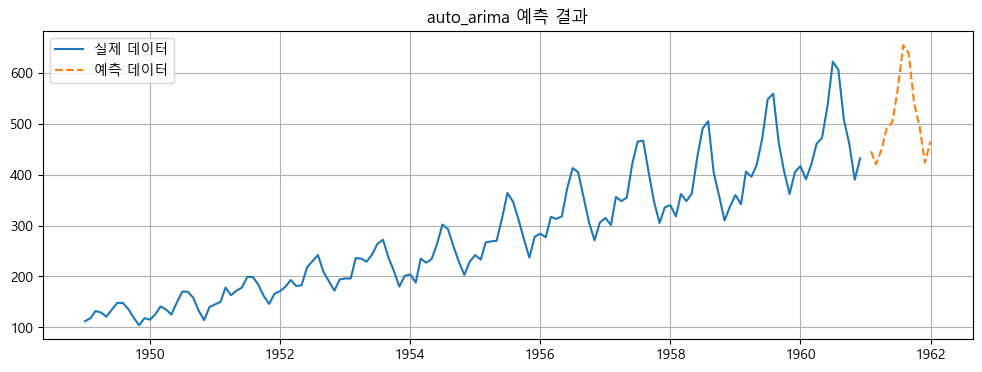

In [ ]:
n_periods = 12
forecast = stepwise_model.predict(n_periods=n_periods)

# 6️ 실제 + 예측 시각화
plt.plot(airDF['passengers'], label='실제 데이터')
plt.plot(pd.date_range(start=airDF['passengers'].index[-1], 
                        periods=n_periods+1, freq='ME')[1:], 
                        forecast, label='예측 데이터', linestyle='--')
plt.title("auto_arima 예측 결과")
plt.legend()
plt.grid(True)
plt.show()
